#Загрузка данных и импорты

In [1]:
!pip install torchinfo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torch.utils.tensorboard import SummaryWriter
import torchinfo

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cpu')

In [3]:
df = pd.read_csv('after_eda_data_rating.csv', index_col=0)
df.head()

,Цена,Оценка циана,Общая площадь,Жилая площадь,Площадь кухни,Этаж,Год постройки,Описание,Хорошая цена,Условие сделки,...,desc_emb_303,desc_emb_304,desc_emb_305,desc_emb_306,desc_emb_307,desc_emb_308,desc_emb_309,desc_emb_310,desc_emb_311,rating
0,4466000,4200000,40.6,19.1,9.5,1,2017,Продается уютная однокомнатная квартира с косм...,1,свободная продажа,...,0.060290,-0.022536,0.017062,-0.012771,-0.026181,-0.057877,0.128278,0.012155,-0.041353,3
1,5200000,5200000,39.2,17.2,10.5,13,2012,"Продаётся 1-комнатная квартира 39,2 кв. м на у...",0,свободная продажа,...,0.019254,-0.050302,0.093703,-0.051701,-0.029761,-0.018555,0.010205,0.059350,-0.014193,3
2,4590000,4590000,34.4,15.0,9.0,8,2011,Код объекта: 2185961.\nПродается однокомнатная...,1,свободная продажа,...,0.035512,-0.038226,0.018210,-0.031785,0.019678,0.069821,-0.003152,0.063423,-0.070235,2
3,3800000,3800000,31.5,12.5,12.5,15,2018,"СРОЧНАЯ ПРОДАЖА!\nЛучшее предложение, таких пл...",1,свободная продажа,...,0.008774,-0.035177,0.050304,-0.031724,-0.041051,-0.021697,0.088250,0.023665,-0.076405,5
4,4190000,4190000,35.0,19.0,9.0,16,1980,Объект N 198283. Однокомнатная квартира в 15 м...,1,свободная продажа,...,0.069608,-0.056068,-0.016646,-0.077126,0.002547,-0.010311,0.027901,0.048601,-0.063243,3


In [4]:
df.shape

(4290, 373)

#Предобработка

Подготовим данные для нейросети: логарифмируем цены (чтобы сжать разброс), разобъем выборку на трейн, тест и валидацию, стандартизируем числовые признаки, превратим категориальные в one-hot.

In [5]:
price = ['Оценка циана', 'Цены квартир рядом (за квадрат)', 'Хорошая цена', 'Цена']

data = df.copy()
data = data.drop(columns = ['id', 'Описание'])

cat = [c for c in data.columns if data[c].dtype == 'object']
emb = [c for c in data.columns if c.startswith('desc_emb_')]
num = [c for c in data.columns if c not in price and c not in cat and c not in emb]

y = np.log1p(data['Цена'].values).astype(np.float32)
tr, te = train_test_split(np.arange(len(data)), test_size=0.15, random_state=42)
tr, va = train_test_split(tr, test_size=0.176, random_state=42)

sc = StandardScaler()
en = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_num = data[num].iloc[tr].values
X_cat = data[cat].iloc[tr].values
X_emb = data[emb].iloc[tr].values
X_num_sc = sc.fit_transform(X_num)
X_cat_enc = en.fit_transform(X_cat)
X_tr = np.hstack([X_num_sc, X_cat_enc, X_emb]).astype(np.float32)

X_num_v = sc.transform(data[num].iloc[va].values)
X_cat_v = en.transform(data[cat].iloc[va].values)
X_emb_v = data[emb].iloc[va].values
X_va = np.hstack([X_num_v, X_cat_v, X_emb_v]).astype(np.float32)

X_num_t = sc.transform(data[num].iloc[te].values)
X_cat_t = en.transform(data[cat].iloc[te].values)
X_emb_t = data[emb].iloc[te].values
X_te = np.hstack([X_num_t, X_cat_t, X_emb_t]).astype(np.float32)

y_tr, y_va, y_te = y[tr], y[va], y[te]
print(f'Число признаков на входе: {X_tr.shape[1]}')

Число признаков на входе: 410


# Архитектуры сетей

Для нашей задачи попробуем 3 разные архитектуры полносвязных нейросетей.

Для всех моделей использовались одинаковые гиперпараметры:

- скорость обучения 1e-3 обеспечивает устойчивую сходимость
- weight decay = 1e-4 - небольшая L2-регуляризация, помогающая предотвращать переобучение
- batch size = 256 - стандартное значение, позволяющее балансировать между скоростью обучения и стабильностью оценки градиента, особенно хорошо в нашем случае не сильно большого датасета.

ShallowMLP - это однослойная сеть с 256 нейронами и функцией активации ReLU. Выберем ее в качестве базы, чтобы оценить, насколько резонно усложнять архитектуру


WideDropoutMLP - архитектура с двумя параллельными ветвями: широкая (512 нейронов) и узкая (128 нейронов), с последующим слиянием. Эта архитектура может быть полезна, потому что в данных больше 400 признаков, могут быть сильные и шумовые. Широкая ветвь хорошо улавливает нелинейные связи, а узкая более устойчивые. Высокий dropout и нормализация помогают бороться с переобучением.

ResidualMLP - архитектура с тремя скрытыми слоями (по 256 нейронов) и skip-соединениями. Глубокие сети зачастую хуже обучаются из-за затухания градиента, skip-связи упрощают этот процесс. С помощью данной архитектуры посмотрим, полезна ли в нашей задаче глубина нейросети.



In [6]:
class ShallowMLP(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, 256)
        self.act = nn.ReLU()
        self.fc2 = nn.Linear(256, 1)
    def forward(self, x):
        x = self.act(self.fc1(x))
        return self.fc2(x)

class WideDropoutMLP(nn.Module):
    def __init__(self, dim, dropout=0.5):
        super().__init__()
        self.wide = nn.Sequential(nn.Linear(dim, 512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dropout))
        self.narrow = nn.Sequential(nn.Linear(dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout))
        self.fc = nn.Linear(512+128, 1)
    def forward(self, x):
        w = self.wide(x)
        n = self.narrow(x)
        return self.fc(torch.cat([w, n], dim=1))

class ResidualMLP(nn.Module):
    def __init__(self, dim, hidden=256, dropout=0.5):
        super().__init__()
        self.block1 = nn.Sequential(nn.Linear(dim, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout))
        self.block2 = nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout))
        self.block3 = nn.Sequential(nn.Linear(hidden, hidden), nn.BatchNorm1d(hidden), nn.ReLU(), nn.Dropout(dropout))
        self.fc = nn.Linear(hidden, 1)
    def forward(self, x):
        x = self.block1(x)
        x = x + self.block2(x)
        x = x + self.block3(x)
        return self.fc(x)

# Прогон и выбор лучшей архитектуры

In [7]:
def metr_func(model, loader, y_m, y_std):
    model.eval()
    preds = []
    trues = []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb.to(device)).cpu().numpy())
            trues.append(yb.numpy())
    p = np.concatenate(preds).ravel()
    t = np.concatenate(trues).ravel()

    p = np.expm1(y_m + p * y_std)
    t= np.expm1(y_m + t * y_std)

    return {'MAE': mean_absolute_error(t, p),
            'RMSE': np.sqrt(mean_squared_error(t, p)),
            'MAPE': mean_absolute_percentage_error(t, p) * 100,
            'R2': r2_score(t, p),
            'pred': p,
            'true': t}

In [19]:
def train_model(m, opt, sched, epochs, name, loaders, y_m, y_std):
    crit = nn.SmoothL1Loss()

    for e in range(1, epochs + 1):
        m.train()
        s = 0
        c = 0
        for xb, yb in loaders['train']:
            xb = xb.to(device)
            yb = yb.to(device)
            opt.zero_grad()
            loss = crit(m(xb), yb)
            loss.backward()
            opt.step()
            s += loss.item() * len(xb)
            c += len(xb)
        sched.step()

        val = metr_func(m, loaders['val'], y_m, y_std)

        if e % 10 == 0 or e == 1:
            print(f'Эпоха {e}/{epochs}, loss {round(s/c,4)}, MAE на валидационной {val["MAE"]}')

    torch.save(m.state_dict(), f'{name}.pt')
    test = metr_func(m, loaders['test'], y_m, y_std)
    print(f'{name} на тесте: MAE - {test["MAE"]}, RMSE - {round(test["RMSE"], 2)}, MAPE - {round(test["MAPE"],2)}%, R2 - {round(test["R2"],2)}')
    return test

In [15]:
y_m = y_tr.mean()
y_std = y_tr.std()

def loader_do(X, yv, bs=256, shuffle=False):
    ds = TensorDataset(torch.tensor(X), torch.tensor(yv).unsqueeze(1))
    return DataLoader(ds, batch_size=bs, shuffle=shuffle)

loaders = {'train': loader_do(X_tr, (y_tr - y_m) / y_std, bs=256, shuffle=True),
    'val': loader_do(X_va, (y_va - y_m) / y_std, bs=256),
    'test': loader_do(X_te, (y_te - y_m) / y_std, bs=256)}
dif_modeli = {'ShallowMLP': ShallowMLP(X_tr.shape[1]), 'ResidualMLP': ResidualMLP(X_tr.shape[1]), 'WideDropoutMLP': WideDropoutMLP(X_tr.shape[1])}
metrics = {}

for n, m in dif_modeli.items():
    m = m.to(device)
    print(n)
    print()
    torchinfo.summary(m, input_size=(256, X_tr.shape[1]), verbose=0)
    opt = optim.Adam(m.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = optim.lr_scheduler.StepLR(opt, step_size=20, gamma=0.5)
    met = train_model(m, opt, sched, 80, n, loaders, y_m, y_std)
    metrics[n] = met
    print()

ShallowMLP

Эпоха 1/80, loss 0.2391, MAE на валидационной 3015685.5
Эпоха 10/80, loss 0.0356, MAE на валидационной 2163738.0
Эпоха 20/80, loss 0.0203, MAE на валидационной 2076102.125
Эпоха 30/80, loss 0.014, MAE на валидационной 2089338.875
Эпоха 40/80, loss 0.0102, MAE на валидационной 2034061.5
Эпоха 50/80, loss 0.0083, MAE на валидационной 2036256.75
Эпоха 60/80, loss 0.0072, MAE на валидационной 2044481.25
Эпоха 70/80, loss 0.0063, MAE на валидационной 2033139.25
Эпоха 80/80, loss 0.0058, MAE на валидационной 2034367.75
ShallowMLP на тесте: MAE - 1577951.125, RMSE - 5406505.11, MAPE - 12.79%, R2 - 0.7

ResidualMLP

Эпоха 1/80, loss 0.4539, MAE на валидационной 4082246.25
Эпоха 10/80, loss 0.11, MAE на валидационной 2297816.25
Эпоха 20/80, loss 0.0734, MAE на валидационной 2231410.75
Эпоха 30/80, loss 0.0622, MAE на валидационной 2169779.25
Эпоха 40/80, loss 0.0554, MAE на валидационной 2158070.25
Эпоха 50/80, loss 0.0501, MAE на валидационной 2165309.0
Эпоха 60/80, loss 0.0503, MA

In [16]:
metr = pd.DataFrame(metrics).T[['MAE','RMSE','MAPE','R2']].sort_values('MAE')
round(metr,2)

,MAE,RMSE,MAPE,R2
WideDropoutMLP,1554425.5,5409974.874819,12.78514,0.6983
ShallowMLP,1577951.125,5406505.110881,12.78825,0.698687
ResidualMLP,1583069.75,5480541.751067,13.415577,0.690378


Лучше всего по MAE (1.55 миллиона рублей) проявила себя WideDropoutMLP. При такой архитектуре средний процент отклонения от реальной цены составил 12.8%, что не самый плохой результат. Остальные две архитектуры дали похожие результаты, но все же слегка похуже. У ShallowMLP MAE = 1.58 миллинов, то есть регуляризация и параллельные ветви дали небольшое улучшение. ResidualMLP - самый худший по показателям, вероятно в связи с тем, что сложность архитектуры слишком велика для нашего небольшого объема данных.


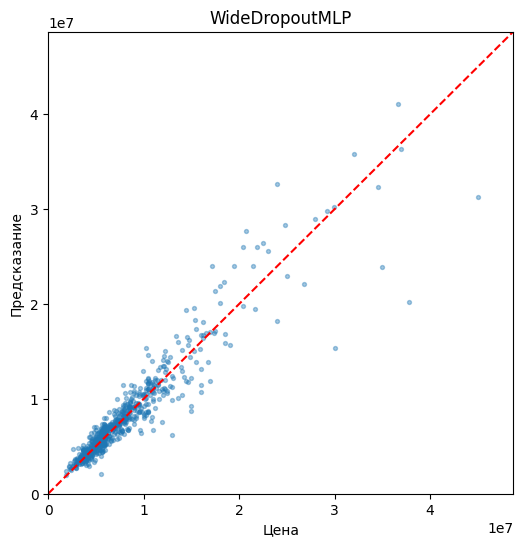

In [17]:
choice = metrics['WideDropoutMLP']
plt.figure(figsize=(6,6))
plt.scatter(choice['true'] , choice['pred'], s=8, alpha=0.4)
lim = [0, np.percentile(choice['true'], 99)]
plt.plot(lim, lim, 'r--')
plt.xlim(lim)
plt.ylim(lim)
plt.xlabel('Цена')
plt.ylabel('Предсказание')
plt.title('WideDropoutMLP')
plt.show()

# Смотрим на влияние признака ratings для лучшей архитектуры

In [20]:
res = {}

for i in range(2):
    num_a = [c for c in num if c != 'rating']
    if i == 0:
        num_a.append('rating')

    sc_a = StandardScaler()
    X_num_a = sc_a.fit_transform(data[num_a].iloc[tr].values)
    X_num_a_v = sc_a.transform(data[num_a].iloc[va].values)
    X_num_a_t = sc_a.transform(data[num_a].iloc[te].values)

    X_tr_a = np.hstack([X_num_a, X_cat_enc, X_emb]).astype(np.float32)
    X_va_a = np.hstack([X_num_a_v, X_cat_v, X_emb_v]).astype(np.float32)
    X_te_a = np.hstack([X_num_a_t, X_cat_t, X_emb_t]).astype(np.float32)

    loaders_a = {
        'train': loader_do(X_tr_a, (y_tr - y_m) / y_std, shuffle=True),
        'val': loader_do(X_va_a, (y_va - y_m) / y_std),
        'test': loader_do(X_te_a, (y_te - y_m) / y_std)
    }

    m_a = WideDropoutMLP(X_tr_a.shape[1]).to(device)
    opt_a = optim.Adam(m_a.parameters(), lr=1e-3, weight_decay=1e-4)
    sch_a = optim.lr_scheduler.StepLR(opt_a, step_size=20, gamma=0.5)

    name_a = f"WideDropoutMLP {'Без рейтинга' if i==1 else 'С рейтингом'}"
    test_a = train_model(m_a, opt_a, sch_a, 80, name_a, loaders_a, y_m, y_std)
    res[f"{'Без рейтинга' if i==1 else 'С рейтингом'}"] = test_a['MAE']

print(f"MAE без рейтинга: {res['Без рейтинга']}")
print(f"MAE с признаком rating: {res['С рейтингом']}")
print(f"Выигрыш от признака rating: {res['Без рейтинга'] - res['С рейтингом']}")

Эпоха 1/80, loss 0.2206, MAE на валидационной 4099413.75
Эпоха 10/80, loss 0.0501, MAE на валидационной 2147965.5
Эпоха 20/80, loss 0.0374, MAE на валидационной 2118615.5
Эпоха 30/80, loss 0.0299, MAE на валидационной 2097868.25
Эпоха 40/80, loss 0.0272, MAE на валидационной 2095731.25
Эпоха 50/80, loss 0.0275, MAE на валидационной 2066096.25
Эпоха 60/80, loss 0.0259, MAE на валидационной 2073786.625
Эпоха 70/80, loss 0.0242, MAE на валидационной 2056130.0
Эпоха 80/80, loss 0.0233, MAE на валидационной 2055673.25
WideDropoutMLP С рейтингом на тесте: MAE - 1518021.5, RMSE - 5336108.71, MAPE - 12.58%, R2 - 0.71
Эпоха 1/80, loss 0.2298, MAE на валидационной 3993749.25
Эпоха 10/80, loss 0.0482, MAE на валидационной 2267752.0
Эпоха 20/80, loss 0.036, MAE на валидационной 2160556.0
Эпоха 30/80, loss 0.035, MAE на валидационной 2158397.5
Эпоха 40/80, loss 0.0273, MAE на валидационной 2128331.5
Эпоха 50/80, loss 0.0287, MAE на валидационной 2122409.75
Эпоха 60/80, loss 0.0245, MAE на валидацио

На лучшей архитектуре WideDropoutMLP добавление рейтинга фотографий квартиры слегка, но все же снизило MAE (на 34 тысячи рублей). Рейтинг дает нашей моделе немного полезной информации, слегка повышая точность, но стоит признать, что улучшение не колоссальное.
